<a href="https://colab.research.google.com/github/yadavrishikesh/Masterclass-V2-2026/blob/main/module4/code/Assignment_2_Solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Fine-Tuning Pre-trained Transformer Models


## Learning Objectives
- Understand transfer learning and pre-trained models.
- Understand fine-tuning.
- Understand inference vs training.
- Understand practical Transformer workflows.

## Estimated Completion Time: 30 minutes

## Background Knowledge Required: Basic Python


In [ ]:
!pip install transformers datasets accelerate matplotlib


In [ ]:
import torch
import matplotlib.pyplot as plt
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset


## Question 1: Using a Pre-trained Transformer

### (a) Load a pre-trained transformer
Let's use `DistilBERT` fine-tuned for sentiment analysis.


In [ ]:
classifier = pipeline('sentiment-analysis', model='distilbert-base-uncased-finetuned-sst-2-english', return_all_scores=True)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

### (b) Run inference on sample text & (c) Observe predictions


In [ ]:
sample_text = "I absolutely love learning about Transformers!"
predictions = classifier(sample_text)
print('Input:', sample_text)
print('Predictions:', predictions)


Input: I absolutely love learning about Transformers!
Predictions: [{'label': 'POSITIVE', 'score': 0.9997379183769226}]


### (d) Visualize probabilities


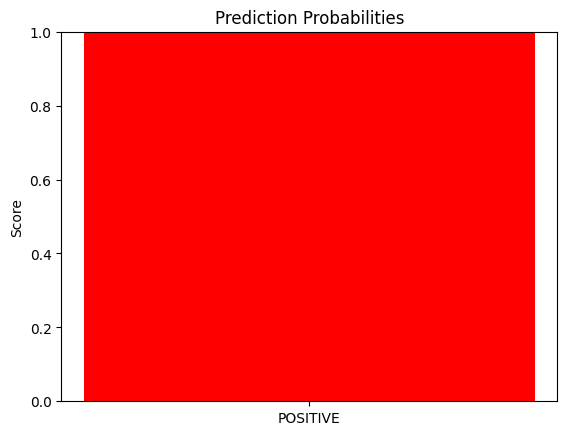

In [ ]:
# Remove the [0] so you iterate through the list of dictionaries directly
labels = [pred['label'] for pred in predictions]
scores = [pred['score'] for pred in predictions]

plt.bar(labels, scores, color=['red', 'green'])
plt.title('Prediction Probabilities')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.show()


### (e) Test multiple sentences


In [ ]:
sentences = [
    "The weather is terrible today.",
    "The pizza was okay, but I've had better.",
    "This workshop is highly educational!"
]
for s in sentences:
    print(f'"{s}" -> {classifier(s)[0]}')


"The weather is terrible today." -> {'label': 'NEGATIVE', 'score': 0.9986808896064758}
"The pizza was okay, but I've had better." -> {'label': 'NEGATIVE', 'score': 0.8841291069984436}
"This workshop is highly educational!" -> {'label': 'POSITIVE', 'score': 0.9997267127037048}


### (f) Reflection: Why does a model trained by someone else already work?


**Solution:** Pre-trained models have already learned representations of language (grammar, syntax, semantics, and sentiment context) by reading vast amounts of data available on the internet. We can use this general knowledge off-the-shelf without training from scratch.


### (g) Reflection: Explain transfer learning intuitively


**Solution:** Transfer learning is akin to an athlete crossing over to a new sport. Someone who knows how to ride a bicycle can learn to ride a motorcycle much faster. They don't start from square one; they reuse their prior knowledge of balance and steering.


## Question 2: Fine-Tuning a Transformer

### (a) Load a small dataset
Let's use a tiny chunk of the 'dair-ai/emotion' dataset for faster training.


In [ ]:
dataset = load_dataset('dair-ai/emotion', split='train[:200]')
val_dataset = load_dataset('dair-ai/emotion', split='validation[:50]')
print(dataset[0])


README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

{'text': 'i didnt feel humiliated', 'label': 0}


### (b) Explore class labels


In [ ]:
print('Features:', dataset.features)
names = dataset.features['label'].names
print('Available Emotions:', names)


Features: {'text': Value('string'), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}
Available Emotions: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


### (c) Fine-tune DistilBERT on a small subset


In [ ]:
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
model = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=6)

def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_train = dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    logging_steps=10,
    eval_strategy='epoch'
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val
)

# Run the fine-tuning!
trainer.train()


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/50 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,1.538593,1.518163
2,1.329181,1.212771
3,1.120788,1.146104


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=75, training_loss=1.4021198399861654, metrics={'train_runtime': 427.007, 'train_samples_per_second': 1.405, 'train_steps_per_second': 0.176, 'total_flos': 19871527219200.0, 'train_loss': 1.4021198399861654, 'epoch': 3.0})

### (d) Track training loss & (e) Plot training progress


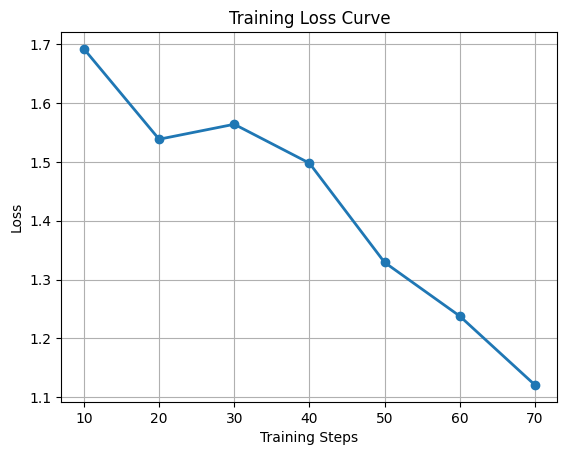

In [ ]:
history = trainer.state.log_history
losses = [x['loss'] for x in history if 'loss' in x]
steps = [x['step'] for x in history if 'loss' in x]

plt.plot(steps, losses, marker='o', linewidth=2)
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True)
plt.show()


### (f) Evaluate performance & (g) Compare: Before vs After fine-tuning


In [ ]:
test_text = 'I feel so incredibly lost and sad today.'

inputs = tokenizer(test_text, return_tensors='pt').to(model.device)
with torch.no_grad():
    logits = model(**inputs).logits

pred_id = torch.argmax(logits, dim=-1).item()
print(f'Prediction for "{test_text}":', names[pred_id])

# Before fine-tuning, the randomly initialized classification head would have spit out garbage predictions.
# After, it mapped the latent knowledge DistilBERT had to our specific 6 emotion classes.


Prediction for "I feel so incredibly lost and sad today.": sadness


### (h) Reflection: What knowledge did the model already have?


**Solution:** The model already intimately understood English language structure, semantics, combinations of words, and sentiment indicators from its immense pre-training corpus (BookCorpus and Wikipedia).


### (i) Reflection: What new knowledge did fine-tuning add?


**Solution:** Fine-tuning added the specific mapping of raw language representations to the 6 discrete emotional categories of our dataset. It just re-aligned its pre-existing "understanding" to our custom output bins.
